In [1]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx, n_photon


def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']
    opts = args['opts']

    H0, H1, H2, H_int, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 + H2 + H_int, [H1, h_t]]

    # initial state (fully polarized + vacuum)

    en, st = Sx.eigenstates()
    a = np.where(np.isclose(en, max(en)))
    psi_spin = st[a[0][0]]
    psi_ph = basis(n_ph, 0)
    psi0 = tensor(psi_spin, psi_ph)
    # evolve
    result = mesolve(H_td,psi0,tlist,[],[n_photon],args=args,options=opts)

    #op_Sx_avg = np.average(result.expect[0])
    #op_Sz_avg = np.average(result.expect[1])
    op_n_photon = result.expect[0]

    return op_n_photon



100%|██████████| 1/1 [00:00<00:00, 550.22it/s]


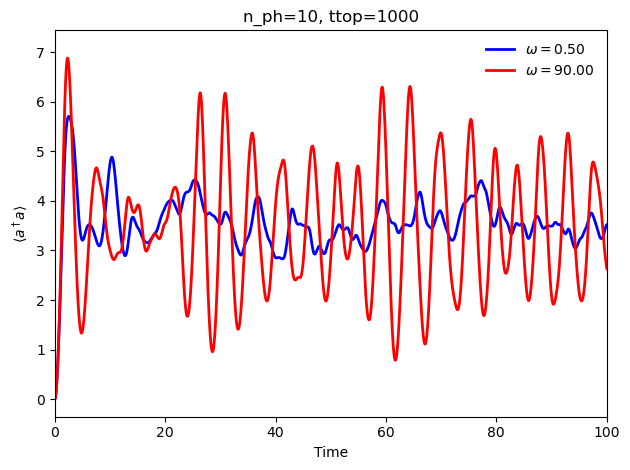

In [ ]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
h0 = 0
n_ph = 10
g = 0.5
omega0 = 1.0
Jvalue = 1.0

omegas = [0.5,90]
x = 2.40
colors = ['blue', 'red']


# time
ttop = 1000
tlist = np.linspace(0, ttop, ttop * 20 + 1)
opts = Options(nsteps =1e6, num_cpus=1, openmp_threads=1)

#styles = ['-', '--']

for omega,color in zip(omegas, colors):
    
        h = x * omega / 4
        args = {
        'omega': omega,
        'h0': h0,
        'g': g,
        'tlist': tlist,
        'N': N,
        'n_ph': n_ph,
        'hbar': hbar,
        'omega0': omega0,
        'Jvalue': Jvalue,
        'h':h,
        'opts':opts
        }
        
        #parallel run

        p = Pool(processes=8)
        n_photon_t = p.map(run_dynamics_lmg,tqdm([args]))

        p.close()
        p.join()

        n_photon_t = n_photon_t[0]
        np.save(f'N_{N}_n_ph_{n_ph}_g_{g:.2f}_omega_{omega:.2f}_x_{x:.2f}.npy',n_photon_t)
    
        # plot
        plt.plot(tlist,n_photon_t,color=color,linestyle='-',linewidth=2,label=rf'$\omega={omega:.2f}$')


  
plt.xlabel('Time')
plt.xlim(0,100)

plt.ylabel(r'$\langle a^\dagger a \rangle$')
plt.title(f'n_ph={n_ph}, ttop={ttop}')

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(f'photon_number_dynamics_n_ph={n_ph}, ttop={ttop}.png',dpi=300,bbox_inches='tight')

plt.show()

  

 